# CEMS Pipeline

Full pipeline: ERM baseline, CEMS (full second-order), CEMS-L (linear ablation).
Each training run is self-contained; set `SKIP_BASELINE=True` to reload from checkpoint.

## Imports and config

In [1]:
# Cell 1 — Imports & config
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

REPO_ROOT = Path("../..")
sys.path.insert(0, str(REPO_ROOT))

from src.CEMS.dataset import load_datasets, make_splits, _make_wide_df, _image_id_from_path
from src.CEMS.model import BiomassModel
from src.CEMS.metrics import weighted_global_r2, rmse_per_target, TARGETS
from src.CEMS.train import train, train_cems, eval_epoch
from src.CEMS.cems_utils import compute_neigh_size, precompute_knn
from src.CEMS.estimate_id import estimate_id
from torch.utils.data import DataLoader

CACHE_DIR = REPO_ROOT / "src" / "CEMS" / "cache"
CKPT_DIR  = REPO_ROOT / "src" / "CEMS" / "checkpoints"
NOTES_DIR = REPO_ROOT / "src" / "CEMS" / "notes"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
NOTES_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
cfg = dict(
    seed         = 42,
    epochs       = 80,
    lr           = 3e-4,
    weight_decay = 1e-3,
    latent_dim   = 32,
    dropout      = 0.1,
    sigma        = 1e-3,   # CEMS tangent perturbation std (paper default)
    cems_method  = 1,      # batch-centred SVD
)

SKIP_BASELINE = False   # set True to reload baseline.pt instead of re-training

device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Config:", cfg)

Device: mps
Config: {'seed': 42, 'epochs': 80, 'lr': 0.0003, 'weight_decay': 0.001, 'latent_dim': 32, 'dropout': 0.1, 'sigma': 0.001, 'cems_method': 1}


## Data loading

In [2]:
# Cell 2 — Data loading
# Load cached DINOv2 features and build train/val split (GroupKFold fold 0)

features_np = np.load(CACHE_DIR / "features_dinov2.npy")     # (N, 384)
image_ids   = np.load(CACHE_DIR / "image_ids.npy", allow_pickle=True)  # (N,)

CSV_PATH = REPO_ROOT / "data" / "tabular" / "train" / "train.csv"

# Build label array aligned to cache order
df_wide = _make_wide_df(CSV_PATH)
id_to_label = {
    _image_id_from_path(row["image_path"]): row[TARGETS].values.astype(np.float32)
    for _, row in df_wide.iterrows()
}
labels_np = np.stack(
    [id_to_label.get(iid, np.zeros(5, dtype=np.float32)) for iid in image_ids]
)  # (N, 5)

id_to_idx   = {iid: i for i, iid in enumerate(image_ids)}
train_ids, val_ids = make_splits(CSV_PATH)

# Integer indices into the cache arrays
train_idx = [id_to_idx[i] for i in train_ids if i in id_to_idx]
val_idx   = [id_to_idx[i] for i in val_ids   if i in id_to_idx]

X_train_np = features_np[train_idx].astype(np.float32)   # (N_train, 384)
Y_train_np = labels_np[train_idx].astype(np.float32)     # (N_train, 5)

# Fit MinMaxScaler on Y_train (used in CEMS joint space)
y_scaler = MinMaxScaler()
y_scaler.fit(Y_train_np)

# PyTorch Datasets (used for val and ERM baseline training)
train_ds, val_ds = load_datasets(CSV_PATH, CACHE_DIR)

print(f"  N_train={len(train_idx)}  N_val={len(val_idx)}")
print(f"  Features: {X_train_np.shape}   Labels: {Y_train_np.shape}")
print(f"  Y min={Y_train_np.min():.1f}  Y max={Y_train_np.max():.1f}")

  N_train=285  N_val=72
  Features: (285, 384)   Labels: (285, 5)
  Y min=0.0  Y max=185.7


## Neighbourhood precomputation

In [3]:
# Cell 3 — Neighbourhood precomputation
# Compute kNN indices in joint [X_train, Y_train_scaled] space.
# Precomputed once; reused every CEMS epoch.

# Estimate latent d from the cached baseline checkpoint (or from raw features)
baseline_ckpt = CKPT_DIR / "baseline.pt"
if baseline_ckpt.exists():
    ckpt = torch.load(baseline_ckpt, map_location="cpu", weights_only=False)
    _model_tmp = BiomassModel(384, cfg["latent_dim"], 5, cfg["dropout"])
    _model_tmp.load_state_dict(ckpt["model_state_dict"])
    _model_tmp.eval()
    with torch.no_grad():
        latents = _model_tmp.encode(
            torch.tensor(X_train_np)
        ).numpy()
    d_latent_float = estimate_id(latents, label="latent (for neigh_size)")
    d_for_neigh = max(1, int(round(d_latent_float)))
    print(f"  d from baseline latent = {d_latent_float:.2f} → using d={d_for_neigh}")
else:
    d_for_neigh = 5   # from Part 2 result (d ≈ 4.71 → 5)
    print(f"  No baseline checkpoint found, using d={d_for_neigh} from Part 2")

neigh_size = compute_neigh_size(d_for_neigh)
print(f"  d={d_for_neigh}  d+d*(d+1)/2={d_for_neigh + d_for_neigh*(d_for_neigh+1)//2}  "
      f"neigh_size={neigh_size}")

Y_train_scaled_np = y_scaler.transform(Y_train_np).astype(np.float32)

# Use DINOv2 features for the kNN (frozen → static neighbours)
knn_indices = precompute_knn(
    X_train_np, Y_train_scaled_np, neigh_size, device=device
)  # (N_train, neigh_size)
print(f"  knn_indices shape: {knn_indices.shape}")

# Sanity check: average distance to nearest neighbour
XY_joint = np.concatenate([X_train_np, Y_train_scaled_np], axis=1)
anchor   = XY_joint[0]
nn_idx   = knn_indices[0, 1]   # nearest neighbour of point 0
avg_nn_dist = np.linalg.norm(XY_joint - anchor, axis=1).mean()
nn_dist = np.linalg.norm(XY_joint[nn_idx] - anchor)
print(f"  avg pairwise dist={avg_nn_dist:.4f}  nn_dist(point 0)={nn_dist:.4f}")

  [latent (for neigh_size)]  d = 4.23  (method: skdim.TwoNN)
  d from baseline latent = 4.23 → using d=4
  d=4  d+d*(d+1)/2=14  neigh_size=16
  knn_indices shape: (285, 16)
  avg pairwise dist=37.6995  nn_dist(point 0)=16.3402


## Baseline ERM training and validation

In [4]:
# Cell 4 — Baseline (ERM, no CEMS)
# Reproduces the Part 2 result; serves as the reference row in the ablation table.

torch.manual_seed(cfg["seed"])
model_baseline = BiomassModel(384, cfg["latent_dim"], 5, cfg["dropout"]).to(device)

if SKIP_BASELINE and (CKPT_DIR / "baseline.pt").exists():
    ckpt = torch.load(CKPT_DIR / "baseline.pt", map_location=device, weights_only=False)
    model_baseline.load_state_dict(ckpt["model_state_dict"])
    history_baseline = ckpt.get("history", {})
    print("  Loaded baseline from checkpoint.")
else:
    history_baseline = train(
        model_baseline, train_ds, val_ds,
        epochs=cfg["epochs"], lr=cfg["lr"],
        weight_decay=cfg["weight_decay"], seed=cfg["seed"],
        device=device, verbose=True,
    )
    torch.save({"model_state_dict": model_baseline.state_dict(),
                "history": history_baseline},
               CKPT_DIR / "baseline.pt")

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
_, r2_baseline, rmse_baseline, _, _ = eval_epoch(model_baseline, val_loader, device)
print(f"\nBaseline  val R²={r2_baseline:.4f}")
for t in TARGETS:
    print(f"  RMSE {t:<18}: {rmse_baseline[t]:.4f}")

  ep   1  tr_loss=6.5501  val_loss=6.9354  val_R²=-1.0598  [Green:37.43  Dead:16.04  Clover:14.91  g:43.50  Total:53.86]
  ep  10  tr_loss=3.2102  val_loss=3.2815  val_R²=0.2948  [Green:24.97  Dead:12.03  Clover:13.80  g:26.07  Total:25.80]
  ep  20  tr_loss=2.3402  val_loss=2.3757  val_R²=0.5749  [Green:19.30  Dead:11.21  Clover:13.83  g:18.39  Total:16.89]
  ep  30  tr_loss=2.1457  val_loss=2.1522  val_R²=0.6353  [Green:17.40  Dead:11.20  Clover:13.85  g:16.00  Total:15.43]
  ep  40  tr_loss=1.8277  val_loss=2.0607  val_R²=0.6627  [Green:16.81  Dead:11.21  Clover:13.58  g:14.73  Total:14.88]
  ep  50  tr_loss=1.9586  val_loss=2.0081  val_R²=0.6731  [Green:16.41  Dead:11.23  Clover:13.75  g:14.11  Total:14.60]
  ep  60  tr_loss=1.8618  val_loss=1.9812  val_R²=0.6833  [Green:16.12  Dead:11.20  Clover:13.61  g:13.77  Total:14.43]
  ep  70  tr_loss=1.7978  val_loss=1.9903  val_R²=0.6796  [Green:16.23  Dead:11.21  Clover:13.62  g:13.82  Total:14.57]
  ep  80  tr_loss=1.8502  val_loss=1.98

## Full CEMS with hessian on latent space

In [6]:
# Cell 5 — CEMS full (with Hessian)

cems_args_full = SimpleNamespace(
    sigma       = cfg["sigma"],
    cems_method = cfg["cems_method"],
    id          = d_for_neigh,
    use_hessian = True,
)

torch.manual_seed(cfg["seed"])
model_cems_full = BiomassModel(384, cfg["latent_dim"], 5, cfg["dropout"]).to(device)

history_cems_full = train_cems(
    model=model_cems_full,
    X_train=X_train_np,
    Y_train_raw=Y_train_np,
    val_ds=val_ds,
    knn_indices=knn_indices,
    scaler=y_scaler,
    args=cems_args_full,
    neigh_size=neigh_size,
    epochs=cfg["epochs"],
    lr=cfg["lr"],
    weight_decay=cfg["weight_decay"],
    seed=cfg["seed"],
    device=device,
    verbose=True,
)

torch.save({"model_state_dict": model_cems_full.state_dict(),
            "history": history_cems_full},
           CKPT_DIR / "cems_full.pt")

_, r2_cems_full, rmse_cems_full, _, _ = eval_epoch(model_cems_full, val_loader, device)
print(f"\nCEMS-full  val R²={r2_cems_full:.4f}")
for t in TARGETS:
    print(f"  RMSE {t:<18}: {rmse_cems_full[t]:.4f}")

  [train_cems] mode=CEMS-full  neigh_size=16  sigma=0.001  epochs=80
  ep   1  tr=7.3349  real=3.6666  aug=3.6683  val_loss=2.6228  val_R²=0.4960  [Green:21.25  Dead:10.50  Clover:14.12  g:21.49  Total:18.75]
  ep  10  tr=2.4027  real=1.2061  aug=1.1966  val_loss=1.8974  val_R²=0.7718  [Green:13.21  Dead:9.30  Clover:9.87  g:12.41  Total:14.69]
  ep  20  tr=1.7197  real=0.8703  aug=0.8494  val_loss=1.7302  val_R²=0.8162  [Green:11.99  Dead:8.24  Clover:7.92  g:11.95  Total:14.17]
  ep  30  tr=1.5101  real=0.7497  aug=0.7604  val_loss=1.7673  val_R²=0.8109  [Green:11.88  Dead:7.94  Clover:7.84  g:12.18  Total:14.42]
  ep  40  tr=1.3071  real=0.6613  aug=0.6458  val_loss=1.7304  val_R²=0.8156  [Green:11.70  Dead:8.18  Clover:7.77  g:12.08  Total:14.40]
  ep  50  tr=1.1892  real=0.5969  aug=0.5923  val_loss=1.7353  val_R²=0.8076  [Green:12.05  Dead:7.65  Clover:7.73  g:12.54  Total:14.46]
  ep  60  tr=1.1590  real=0.5781  aug=0.5809  val_loss=1.7512  val_R²=0.8105  [Green:11.88  Dead:7.69

## First order CEMS ablation (no Hessian)

In [7]:
# Cell 6 — CEMS-L ablation (no Hessian, first-order only)

cems_args_linear = SimpleNamespace(
    sigma       = cfg["sigma"],
    cems_method = cfg["cems_method"],
    id          = d_for_neigh,
    use_hessian = False,
)

torch.manual_seed(cfg["seed"])
model_cems_linear = BiomassModel(384, cfg["latent_dim"], 5, cfg["dropout"]).to(device)

history_cems_linear = train_cems(
    model=model_cems_linear,
    X_train=X_train_np,
    Y_train_raw=Y_train_np,
    val_ds=val_ds,
    knn_indices=knn_indices,
    scaler=y_scaler,
    args=cems_args_linear,
    neigh_size=neigh_size,
    epochs=cfg["epochs"],
    lr=cfg["lr"],
    weight_decay=cfg["weight_decay"],
    seed=cfg["seed"],
    device=device,
    verbose=True,
)

torch.save({"model_state_dict": model_cems_linear.state_dict(),
            "history": history_cems_linear},
           CKPT_DIR / "cems_linear.pt")

_, r2_cems_linear, rmse_cems_linear, _, _ = eval_epoch(model_cems_linear, val_loader, device)
print(f"\nCEMS-L  val R²={r2_cems_linear:.4f}")
for t in TARGETS:
    print(f"  RMSE {t:<18}: {rmse_cems_linear[t]:.4f}")

  [train_cems] mode=CEMS-L (linear)  neigh_size=16  sigma=0.001  epochs=80
  ep   1  tr=7.3349  real=3.6666  aug=3.6683  val_loss=2.6228  val_R²=0.4960  [Green:21.25  Dead:10.50  Clover:14.12  g:21.49  Total:18.75]
  ep  10  tr=2.4057  real=1.2070  aug=1.1987  val_loss=1.9172  val_R²=0.7724  [Green:13.23  Dead:9.34  Clover:9.84  g:12.55  Total:14.99]
  ep  20  tr=1.7183  real=0.8687  aug=0.8496  val_loss=1.7431  val_R²=0.8171  [Green:11.99  Dead:8.25  Clover:7.92  g:11.97  Total:14.25]
  ep  30  tr=1.5085  real=0.7492  aug=0.7593  val_loss=1.7769  val_R²=0.8103  [Green:11.88  Dead:7.96  Clover:7.86  g:12.21  Total:14.37]
  ep  40  tr=1.3028  real=0.6579  aug=0.6448  val_loss=1.7443  val_R²=0.8155  [Green:11.75  Dead:8.14  Clover:7.82  g:12.21  Total:14.47]
  ep  50  tr=1.1905  real=0.5966  aug=0.5939  val_loss=1.7372  val_R²=0.8064  [Green:12.08  Dead:7.73  Clover:7.75  g:12.51  Total:14.39]
  ep  60  tr=1.1616  real=0.5794  aug=0.5822  val_loss=1.7441  val_R²=0.8116  [Green:11.82  Dea

## Ablation table

In [8]:
# Cell 7 — Ablation table

header = f"{'Method':<14} | {'Val R²':>6} | " + " | ".join(f"{t.split('_')[1]:>8}" for t in TARGETS)
sep    = "-" * len(header)
print(sep)
print(header)
print(sep)

rows = [
    ("Baseline",    r2_baseline,    rmse_baseline),
    ("CEMS-L",      r2_cems_linear, rmse_cems_linear),
    ("CEMS (full)", r2_cems_full,   rmse_cems_full),
]
for name, r2, rmse in rows:
    rmse_vals = " | ".join(f"{rmse[t]:>8.2f}" for t in TARGETS)
    print(f"{name:<14} | {r2:>6.4f} | {rmse_vals}")
print(sep)

------------------------------------------------------------------------------
Method         | Val R² |    Green |     Dead |   Clover |        g |    Total
------------------------------------------------------------------------------
Baseline       | 0.6793 |    16.22 |    11.21 |    13.62 |    13.84 |    14.59
CEMS-L         | 0.8083 |    11.82 |     7.69 |     7.60 |    12.44 |    13.95
CEMS (full)    | 0.8073 |    11.86 |     7.71 |     7.56 |    12.49 |    14.04
------------------------------------------------------------------------------


## Training curves

Saved: ../../src/CEMS/notes/training_curves.png


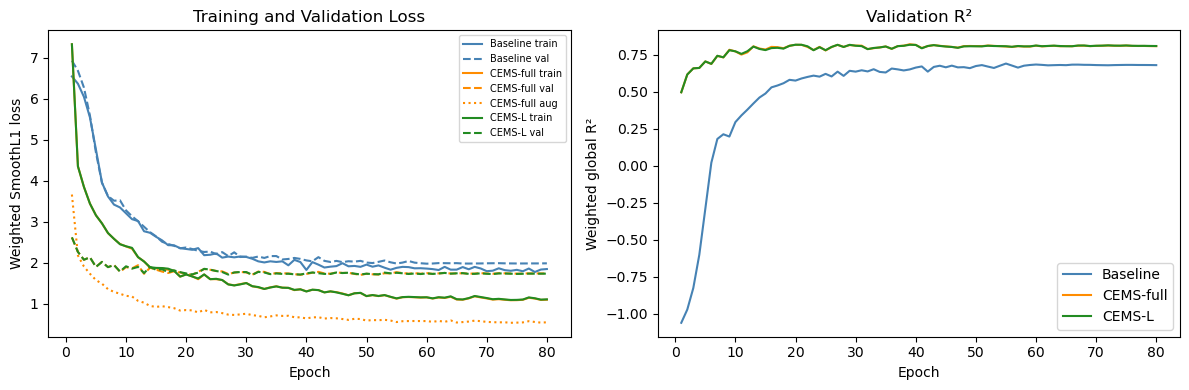

In [9]:
# Cell 8 — Training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Loss curves ---
ax = axes[0]
epochs_range = range(1, cfg["epochs"] + 1)

if history_baseline.get("train_loss"):
    ax.plot(epochs_range, history_baseline["train_loss"], label="Baseline train", color="steelblue")
    ax.plot(epochs_range, history_baseline["val_loss"],   label="Baseline val",   color="steelblue", linestyle="--")

if history_cems_full.get("train_loss"):
    ax.plot(epochs_range, history_cems_full["train_loss"],  label="CEMS-full train", color="darkorange")
    ax.plot(epochs_range, history_cems_full["val_loss"],    label="CEMS-full val",   color="darkorange", linestyle="--")
    ax.plot(epochs_range, history_cems_full["train_loss_aug"], label="CEMS-full aug", color="darkorange", linestyle=":")

if history_cems_linear.get("train_loss"):
    ax.plot(epochs_range, history_cems_linear["train_loss"], label="CEMS-L train", color="forestgreen")
    ax.plot(epochs_range, history_cems_linear["val_loss"],   label="CEMS-L val",   color="forestgreen", linestyle="--")

ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted SmoothL1 loss")
ax.set_title("Training and Validation Loss")
ax.legend(fontsize=7)

# --- Val R² curves ---
ax = axes[1]
if history_baseline.get("val_r2"):
    ax.plot(epochs_range, history_baseline["val_r2"],    label="Baseline",    color="steelblue")
if history_cems_full.get("val_r2"):
    ax.plot(epochs_range, history_cems_full["val_r2"],   label="CEMS-full",   color="darkorange")
if history_cems_linear.get("val_r2"):
    ax.plot(epochs_range, history_cems_linear["val_r2"], label="CEMS-L",      color="forestgreen")

ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted global R²")
ax.set_title("Validation R²")
ax.legend()

plt.tight_layout()
out_path = NOTES_DIR / "training_curves.png"
plt.savefig(out_path, dpi=150)
print(f"Saved: {out_path}")
plt.show()

## Kaggle submission with best CEMS model

In [11]:
# Cell 9 (optional) — Kaggle submission with best CEMS model
# Skipped if CEMS did not improve over baseline.

best_r2   = max(r2_baseline, r2_cems_full, r2_cems_linear)
best_name = ["Baseline", "CEMS-full", "CEMS-L"][
    [r2_baseline, r2_cems_full, r2_cems_linear].index(best_r2)
]
print(f"Best model: {best_name}  val R²={best_r2:.4f}")

if best_r2 <= r2_baseline:
    print("CEMS did not improve over baseline — skipping Kaggle submission.")
else:
    best_model = (
        model_cems_full   if best_name == "CEMS-full" else
        model_cems_linear if best_name == "CEMS-L"    else model_baseline
    )

    # Extract DINOv2 features for test images (one-time if not cached)
    test_feat_path = CACHE_DIR / "test_features_dinov2.npy"
    test_ids_path  = CACHE_DIR / "test_image_ids.npy"

    if not test_feat_path.exists():
        print("  Test features not cached — run extract_features.py for test set first.")
    else:
        import pandas as pd

        test_feats = np.load(test_feat_path).astype(np.float32)
        test_ids   = np.load(test_ids_path, allow_pickle=True)

        best_model.eval()
        with torch.no_grad():
            preds = best_model(
                torch.tensor(test_feats, dtype=torch.float32, device=device)
            ).cpu().numpy()

        # Build submission DataFrame
        records = []
        for img_id, pred_row in zip(test_ids, preds):
            for t_idx, target in enumerate(TARGETS):
                records.append({"sample_id": f"{img_id}__{target}",
                                "target": float(pred_row[t_idx])})
        sub_df = pd.DataFrame(records)
        sub_path = REPO_ROOT / "src" / "CEMS" / f"submission_{best_name.replace(' ', '_')}.csv"
        sub_df.to_csv(sub_path, index=False)
        print(f"  Submission saved: {sub_path}  ({len(sub_df)} rows)")

Best model: CEMS-L  val R²=0.8083
  Submission saved: ../../src/CEMS/submission_CEMS-L.csv  (5 rows)
